<a href="https://colab.research.google.com/github/phuy29032007/Pham-Huy-BT-Ca-Nhan/blob/main/bt_c%C3%A1_nh%C3%A2n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 1705 images belonging to 36 classes.
Found 422 images belonging to 36 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,284 (12.62 MB)

 Trainable params: 3,309,284 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 556s 10s/step - accuracy: 0.0680 - loss: 3.5141 - val_accuracy: 0.0972 - val_loss: 3.3309
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.1255 - loss: 3.2271 - val_accuracy: 0.1730 - val_loss: 2.9733
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.1894 - loss: 2.9155 - val_accuracy: 0.3957 - val_loss: 2.3690
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.3413 - loss: 2.3944 - val_accuracy: 0.4953 - val_loss: 2.0229
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.4205 - loss: 2.0799 - val_accuracy: 0.5806 - val_loss: 1.7502
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4974 - loss: 1.7954 - val_accuracy: 0.6398 - val_loss: 1.5568
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5337 - loss: 1.6985 - val_accuracy: 0.6872 - val_loss: 1.3289
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6106 - loss: 1.4136 - val_accuracy: 0.7488 - val_los

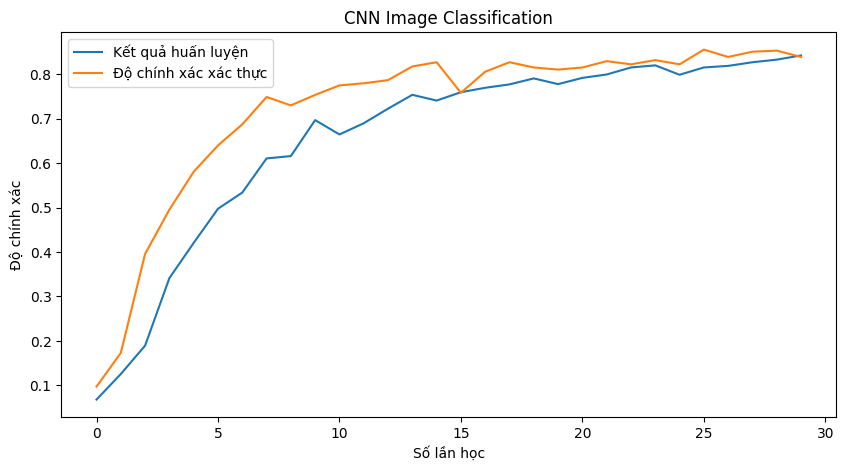

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


# 1. TIỀN XỬ LÝ DỮ LIỆU


# Đường dẫn dataset
train_dir = "/content/drive/MyDrive/anhselfie"

# Kích thước ảnh
img_width, img_height = 128, 128

# Batch size
batch_size = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)


# TẠO TẬP TRAIN


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# TẠO TẬP VALIDATION

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Số lớp
num_classes = train_generator.num_classes

# 2. XÂY DỰNG MÔ HÌNH CNN

model = Sequential([

    # Layer 1
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(img_width, img_height, 3)
    ),
    MaxPooling2D(2,2),

    # Layer 2
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Layer 3
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),

    # Dense Layer
    Dense(128, activation="relu"),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation="softmax")
])

# 3. BIÊN DỊCH MÔ HÌNH

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Hiển thị cấu trúc model
model.summary()

# 4. HUẤN LUYỆN MÔ HÌNH
epochs = 30

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

# 5. VẼ BIỂU ĐỒ ĐỘ CHÍNH XÁC

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label="Kết quả huấn luyện"
)

plt.plot(
    history.history['val_accuracy'],
    label="Độ chính xác xác thực"
)

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")

plt.title("CNN Image Classification")

plt.legend()

plt.show()

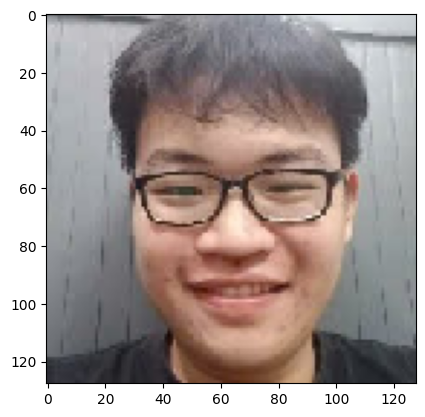

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Người tiên đoán: Lê Thanh Trung Quốc


In [ ]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np

path = "/content/IMG_1779042958637_1779043066067.jpg"
# Tiên đoán loại
img = load_img(path, target_size=(128, 128))

plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}

person_name = class_labels[prediction]

print(f"Người tiên đoán: {person_name}")